# Module 2 — BiLSTM Time-Series Forecaster
### Agent-Based Digital Twin | Frozen Fruit Quality

---
**What this module does:**
Takes IoT sensor sequences (Temp, Humid, CO₂, Light) and predicts:
- Quality Score (0.0 – 1.0) — regression
- Quality Class (Fresh / Slightly Degraded / Spoiled) — classification

**Dataset:**
- 24,501 synthetic sensor sequences (matched to Module 1 image counts)
- Mendeley real sensor CSV used as training augmentation

**Architecture:**
```
Input (30 timesteps × 4 features)
  → BiLSTM Layer 1  (128 units bidirectional)
  → Attention Layer (learns which timesteps matter)
  → BiLSTM Layer 2  (64 units bidirectional)
  → Dense(256)      ← 256-dim embedding → Module 3
  → Head 1: quality_score  (sigmoid)
  → Head 2: quality_class  (softmax 3)
```

**Targets:** RMSE < 0.15 | Accuracy > 80%

---
**Before running:** Runtime → Change runtime type → T4 GPU

---
## CELL 1 — Install & Import

In [ ]:
# ================================================================
# CELL 1: Install & Import
# ================================================================
!pip install -q scikit-learn tqdm

import os, math, random, warnings, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

CLASS_NAMES  = ['Fresh', 'Slightly Degraded', 'Spoiled']
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']
FRUIT_LIST   = ['apple', 'banana', 'orange']
FRUIT_COLORS = ['#c0392b', '#f1c40f', '#e67e22']
TIMESTEPS    = 30
N_FEATURES   = 4
R_GAS        = 8.314

OUT_DIR = Path('/content/module2_outputs')
OUT_DIR.mkdir(exist_ok=True)



---
## CELL 2 — Mount Google Drive

In [ ]:
# ================================================================
# CELL 2: Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/gdrive')

DRIVE_DIR = Path('/gdrive/MyDrive/FrozenFruitModule2')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Drive mounted. Saving to: {DRIVE_DIR}')

Mounted at /gdrive
Drive mounted. Saving to: /gdrive/MyDrive/FrozenFruitModule2


---
## CELL 3 — Load Mendeley CSV from Google Drive

In [ ]:
# ================================================================
# CELL 3: Load Mendeley CSV
# Only uses sensor columns: Temp, Humid, CO2, Light
# Drops Fruit and Class columns completely
# ================================================================

# ---- SET YOUR CSV PATH HERE ----
CSV_PATH = '/gdrive/MyDrive/Colab Notebooks/cold_storage_fruit_spoilage.csv'
# --------------------------------

df_mendeley   = None
USE_REAL_DATA = False

try:
    df_mendeley = pd.read_csv(CSV_PATH)

    # Clean column names
    df_mendeley.columns = [c.strip().lower() for c in df_mendeley.columns]
    print(f'Loaded: {df_mendeley.shape}')
    print(f'All columns: {list(df_mendeley.columns)}')

    # Drop Fruit and Class columns — we only want sensor readings
    drop_cols = [c for c in df_mendeley.columns
                 if any(k in c for k in ['fruit','class','label','type','name'])]
    if drop_cols:
        df_mendeley = df_mendeley.drop(columns=drop_cols)
        print(f'Dropped : {drop_cols}')

    # Keep only numeric sensor columns
    df_mendeley = df_mendeley.select_dtypes(include=[np.number]).dropna()
    print(f'Sensor columns kept: {list(df_mendeley.columns)}')
    print(f'Final shape: {df_mendeley.shape}')
    print(f'\nSensor statistics:')
    print(df_mendeley.describe().round(2).to_string())

    USE_REAL_DATA = True

except FileNotFoundError:
    print(f'CSV not found at: {CSV_PATH}')
    print('Update CSV_PATH above with your actual file path.')
    print('Continuing with synthetic data only.')

Loaded: (10995, 6)
All columns: ['fruit', 'temp', 'humid (%)', 'light (fux)', 'co2 (pmm)', 'class']
Dropped : ['fruit', 'class']
Sensor columns kept: ['temp', 'humid (%)', 'light (fux)', 'co2 (pmm)']
Final shape: (10995, 4)

Sensor statistics:
           temp  humid (%)  light (fux)  co2 (pmm)
count  10995.00   10995.00     10995.00   10995.00
mean      23.84      93.53        24.93     319.53
std        1.23       3.00        48.02      58.89
min       21.00      71.00         4.22      20.00
25%       23.00      94.00         9.93     289.00
50%       24.00      95.00        12.91     323.00
75%       25.00      95.00        15.59     359.00
max       27.00      95.00       268.45     478.00


---
## CELL 4 — Module 1 Counts (hardcoded from your screenshot)

In [ ]:
# ================================================================
# CELL 4: Module 1 Image Counts — hardcoded
# These are your exact Module 1 final dataset distribution numbers
# Module 2 will generate the same count of sensor sequences
# ================================================================

# From Module 1 Cell 5 output:
M1 = {
    'train': {'fresh': 4562, 'slightly_degraded': 4562, 'spoiled': 5883},
    'val':   {'fresh': 1722, 'slightly_degraded': 1722, 'spoiled': 2188},
    'test':  {'fresh': 1164, 'slightly_degraded': 1164, 'spoiled': 1534},
}

# Build label arrays — same class distribution as Module 1
# Class 0 = Fresh, 1 = Slightly Degraded, 2 = Spoiled
def make_labels(counts):
    return np.array(
        [0] * counts['fresh'] +
        [1] * counts['slightly_degraded'] +
        [2] * counts['spoiled'],
        dtype=np.int32
    )

TRAIN_LABELS = make_labels(M1['train'])   # (15007,)
VAL_LABELS   = make_labels(M1['val'])     # (5632,)
TEST_LABELS  = make_labels(M1['test'])    # (3862,)

N_TRAIN = len(TRAIN_LABELS)   # 15007
N_VAL   = len(VAL_LABELS)     # 5632
N_TEST  = len(TEST_LABELS)    # 3862
N_TOTAL = N_TRAIN + N_VAL + N_TEST  # 24501

print('Module 1 counts loaded:')
print(f'  Train : {N_TRAIN:,}  '
      f'(Fresh={M1["train"]["fresh"]} | '
      f'SlightlyDeg={M1["train"]["slightly_degraded"]} | '
      f'Spoiled={M1["train"]["spoiled"]})')
print(f'  Val   : {N_VAL:,}  '
      f'(Fresh={M1["val"]["fresh"]} | '
      f'SlightlyDeg={M1["val"]["slightly_degraded"]} | '
      f'Spoiled={M1["val"]["spoiled"]})')
print(f'  Test  : {N_TEST:,}  '
      f'(Fresh={M1["test"]["fresh"]} | '
      f'SlightlyDeg={M1["test"]["slightly_degraded"]} | '
      f'Spoiled={M1["test"]["spoiled"]})')
print(f'  TOTAL : {N_TOTAL:,}')
print(f'\nModule 2 will generate exactly {N_TOTAL:,} sensor sequences.')

Module 1 counts loaded:
  Train : 15,007  (Fresh=4562 | SlightlyDeg=4562 | Spoiled=5883)
  Val   : 5,632  (Fresh=1722 | SlightlyDeg=1722 | Spoiled=2188)
  Test  : 3,862  (Fresh=1164 | SlightlyDeg=1164 | Spoiled=1534)
  TOTAL : 24,501

Module 2 will generate exactly 24,501 sensor sequences.


---
## CELL 5 — Arrhenius Sensor Generator

In [ ]:
# ================================================================
# CELL 5: Arrhenius Sensor Sequence Generator
# Fruit-specific physics parameters + 5 storage scenarios
# ================================================================

FRUIT_PARAMS = {
    'apple': {
        'Ea': 78000, 'base_temp': -18.0, 'humid': 90.0,
        'co2': 450.0, 'shelf_days': 90,
        'cold_sensitive': False, 'ethylene': 0.8
    },
    'banana': {
        'Ea': 71000, 'base_temp': -15.0, 'humid': 88.0,
        'co2': 500.0, 'shelf_days': 60,
        'cold_sensitive': True, 'ethylene': 1.4
    },
    'orange': {
        'Ea': 76000, 'base_temp': -18.0, 'humid': 92.0,
        'co2': 420.0, 'shelf_days': 80,
        'cold_sensitive': False, 'ethylene': 0.6
    },
}

SCENARIOS = ['normal', 'door_opening', 'partial_thaw',
             'compressor_fail', 'freeze_thaw']

# Class → storage conditions
CLASS_CONDITIONS = {
    0: {'day_range': (1,  25), 'score_range': (0.72, 0.97),
        'scenarios': ['normal', 'normal', 'door_opening']},
    1: {'day_range': (20, 55), 'score_range': (0.42, 0.68),
        'scenarios': ['door_opening', 'partial_thaw', 'partial_thaw']},
    2: {'day_range': (50, 90), 'score_range': (0.05, 0.38),
        'scenarios': ['compressor_fail', 'freeze_thaw', 'compressor_fail']},
}


def make_sequence(fruit, scenario, storage_day):
    p     = FRUIT_PARAMS[fruit]
    temp  = p['base_temp'] + np.random.normal(0, 0.4)
    humid = p['humid']     + np.random.normal(0, 1.0)
    co2   = p['co2']       + np.random.normal(0, 15)
    light = 0.0
    day_f = min(storage_day / p['shelf_days'], 1.0)
    T_out, H_out, C_out, L_out = [], [], [], []

    for t in range(TIMESTEPS):
        if scenario == 'normal':
            temp  = np.clip(temp  + np.random.normal(0, 0.15), -22, -14)
            humid = np.clip(humid + np.random.normal(0, 0.4),   80,  98)
            co2   = np.clip(co2   + np.random.normal(0, 6),    350, 700)
            light = np.random.uniform(0, 3)

        elif scenario == 'door_opening':
            if t == 5:
                temp  += np.random.uniform(4, 9)
                humid -= np.random.uniform(8, 18)
                light  = np.random.uniform(200, 700)
                co2   += np.random.uniform(60, 180) * p['ethylene']
            elif 5 < t < 18:
                temp   = max(temp  - np.random.uniform(0.3, 0.8), p['base_temp'])
                humid  = min(humid + np.random.uniform(0.5, 1.5), 97)
                light  = max(light - 60, 0)
                co2   -= np.random.uniform(5, 15)
            else:
                temp  = np.clip(temp  + np.random.normal(0, 0.15), -22, -12)
                humid = np.clip(humid + np.random.normal(0, 0.3),   80,  98)
                co2   = np.clip(co2   + np.random.normal(0, 5),    350, 800)
                light = np.random.uniform(0, 3)

        elif scenario == 'partial_thaw':
            thaw = -8.0 if p['cold_sensitive'] else -5.0
            if t < 12:
                temp += np.random.uniform(0.2, 0.6)
            elif t < 22:
                temp   = np.clip(temp, thaw, -2.0)
                humid  = np.random.uniform(93, 99)
                co2   += np.random.uniform(8, 25) * p['ethylene']
            else:
                temp = max(temp - np.random.uniform(0.3, 0.6), p['base_temp'] - 1)

        elif scenario == 'compressor_fail':
            dr   = 0.35 if p['cold_sensitive'] else 0.25
            temp = min(temp + np.random.uniform(dr*0.8, dr*1.2), 8.0)
            co2  = min(co2  + np.random.uniform(15, 45) * p['ethylene'], 3000)
            light = np.random.uniform(0, 8)

        elif scenario == 'freeze_thaw':
            hi = -8.0 if p['cold_sensitive'] else -4.0
            if t % 10 < 5:
                temp = min(temp + np.random.uniform(0.3, 0.9), hi)
            else:
                temp = max(temp - np.random.uniform(0.3, 0.9), -22)
            co2 = np.clip(co2 + np.random.normal(0, 12)*p['ethylene'], 350, 2000)

        co2 = np.clip(co2 + day_f*np.random.uniform(0,40)*p['ethylene'], 350, 3000)
        T_out.append(float(temp))
        H_out.append(float(np.clip(humid, 40, 100)))
        C_out.append(float(co2))
        L_out.append(float(np.clip(light, 0, 1000)))

    return np.array([T_out, H_out, C_out, L_out], dtype=np.float32).T


def compute_quality(seq, storage_day, fruit):
    p = FRUIT_PARAMS[fruit]
    q = 1.0
    for T in seq[:, 0]:
        k = 1e10 * math.exp(-p['Ea'] / (R_GAS * (T + 273.15)))
        q = max(q * math.exp(-k * 900), 0.0)
    day_pen = math.exp(-0.028 * storage_day * (90 / p['shelf_days']))
    co2_pen = math.exp(-0.00025 * max(seq[:,2].mean() - p['co2']*1.4, 0))
    ft_pen  = math.exp(-0.012  * seq[:,0].var())
    ci_pen  = math.exp(-0.05 * (seq[:,0] < -16.0).sum()) \
              if p['cold_sensitive'] else 1.0
    return float(np.clip(q * day_pen * co2_pen * ft_pen * ci_pen, 0, 1))


print('Sensor generator ready.')
print('Fruit parameters:')
print(f'{"Fruit":8s} {"Ea (kJ/mol)":>12s} {"Base Temp":>10s} {"Shelf Days":>12s}')
print('-' * 46)
for fruit in FRUIT_LIST:
    p = FRUIT_PARAMS[fruit]
    print(f'{fruit.capitalize():8s} {p["Ea"]/1000:>12.0f} '
          f'{p["base_temp"]:>9.1f}°C {p["shelf_days"]:>12d}d')

Sensor generator ready.
Fruit parameters:
Fruit     Ea (kJ/mol)  Base Temp   Shelf Days
----------------------------------------------
Apple              78     -18.0°C           90d
Banana             71     -15.0°C           60d
Orange             76     -18.0°C           80d


---
## CELL 6 — Generate 24,501 Paired Sensor Sequences

In [ ]:
# ================================================================
# CELL 6: Generate exactly 24,501 sensor sequences
# One sequence per Module 1 image — same class label
# Runtime: ~5 minutes
# ================================================================

def generate_split(labels, split_name):
    """
    For each label in the split, generate one matching sensor sequence.
    Class of sequence = class of the corresponding Module 1 image.
    Fruit rotates: apple → banana → orange → apple → ...
    """
    seqs, scores, fruits = [], [], []

    for i, cls in enumerate(tqdm(labels, desc=split_name)):
        cls    = int(cls)
        cond   = CLASS_CONDITIONS[cls]
        fruit  = FRUIT_LIST[i % 3]
        day    = random.randint(*cond['day_range'])
        sc     = random.choice(cond['scenarios'])

        seq    = make_sequence(fruit, sc, day)
        phys_q = compute_quality(seq, day, fruit)

        # Blend Arrhenius physics with class-consistent range
        lo, hi = cond['score_range']
        score  = float(np.clip(
            0.5 * np.random.uniform(lo, hi) + 0.5 * phys_q,
            lo * 0.9, hi * 1.05
        ))

        seqs.append(seq)
        scores.append(score)
        fruits.append(fruit)

    return (
        np.array(seqs,   dtype=np.float32),
        np.array(scores, dtype=np.float32),
        np.array(fruits)
    )


print(f'Generating {N_TOTAL:,} paired sensor sequences...')
print(f'Split: {N_TRAIN} train | {N_VAL} val | {N_TEST} test\n')

train_seqs, train_scores, train_fruits = generate_split(TRAIN_LABELS, 'Train')
val_seqs,   val_scores,   val_fruits   = generate_split(VAL_LABELS,   'Val')
test_seqs,  test_scores,  test_fruits  = generate_split(TEST_LABELS,  'Test')

# ---- Add Mendeley real sensor values to training (augmentation only) ----
if USE_REAL_DATA and df_mendeley is not None:
    print('\nAdding Mendeley real sensor readings to training set...')

    # Find the 4 sensor columns by keyword
    col_map = {}
    for c in df_mendeley.columns:
        if 'temp'  in c: col_map['temp']  = c
        if 'hum'   in c: col_map['humid'] = c
        if 'co2'   in c: col_map['co2']   = c
        if 'light' in c: col_map['light'] = c

    if len(col_map) == 4:
        sensor_data = df_mendeley[
            [col_map['temp'], col_map['humid'],
             col_map['co2'],  col_map['light']]
        ].dropna().values.astype(np.float32)

        real_seqs, real_scores, real_labels_list = [], [], []

        # Sliding windows of 30 timesteps
        for i in range(0, len(sensor_data) - TIMESTEPS, TIMESTEPS):
            window = sensor_data[i:i + TIMESTEPS]
            if window.shape[0] < TIMESTEPS:
                continue
            # Estimate quality from sensor pattern
            mean_temp = window[:, 0].mean()
            temp_var  = window[:, 0].var()
            mean_co2  = window[:, 2].mean()
            sc = float(np.clip(
                0.85
                - 0.02   * max(mean_temp + 18, 0)
                - 0.008  * temp_var
                - 0.0002 * max(mean_co2 - 500, 0),
                0.0, 1.0
            ))
            cls = 0 if sc > 0.70 else (1 if sc > 0.40 else 2)
            real_seqs.append(window)
            real_scores.append(sc)
            real_labels_list.append(cls)

        if real_seqs:
            real_seqs   = np.array(real_seqs,   dtype=np.float32)
            real_scores = np.array(real_scores, dtype=np.float32)
            real_labels = np.array(real_labels_list, dtype=np.int32)
            real_fruits = np.array([random.choice(FRUIT_LIST)
                                    for _ in real_seqs])

            # Append to training only
            train_seqs   = np.vstack([train_seqs,   real_seqs])
            train_scores = np.concatenate([train_scores, real_scores])
            train_fruits = np.concatenate([train_fruits, real_fruits])
            # Labels for real data come from estimated class
            TRAIN_LABELS_FULL = np.concatenate([TRAIN_LABELS, real_labels])
            print(f'  Added {len(real_seqs):,} real sequences.')
            print(f'  Training set now: {len(train_seqs):,}')
        else:
            TRAIN_LABELS_FULL = TRAIN_LABELS.copy()
    else:
        print(f'  Could not find all 4 sensor columns. Found: {col_map}')
        TRAIN_LABELS_FULL = TRAIN_LABELS.copy()
else:
    TRAIN_LABELS_FULL = TRAIN_LABELS.copy()

# ---- Summary ----
print('\n' + '=' * 58)
print('DATASET SUMMARY')
print('=' * 58)
print(f'{"Split":8s} {"Sequences":>12s} {"M1 Images":>12s}')
print('-' * 35)
print(f'{"Train":8s} {len(train_seqs):>12,} {N_TRAIN:>12,}')
print(f'{"Val":8s} {len(val_seqs):>12,} {N_VAL:>12,}')
print(f'{"Test":8s} {len(test_seqs):>12,} {N_TEST:>12,}')
print('=' * 58)
print('\nClass distribution check (train, first N_TRAIN rows):')
for i, name in enumerate(CLASS_NAMES):
    n_m1 = (TRAIN_LABELS == i).sum()
    n_m2 = (TRAIN_LABELS_FULL[:N_TRAIN] == i).sum()
    print(f'  {name:22s}: M1={n_m1:5d} | M2={n_m2:5d}')
print('\nQuality score ranges:')
for i, name in enumerate(CLASS_NAMES):
    mask = TRAIN_LABELS == i
    sc   = train_scores[:N_TRAIN][mask]
    print(f'  {name:22s}: {sc.min():.3f} – {sc.max():.3f}'
          f'  (mean={sc.mean():.3f})')

Generating 24,501 paired sensor sequences...
Split: 15007 train | 5632 val | 3862 test



Test: 100%|██████████| 3862/3862 [00:05<00:00, 664.29it/s]


Adding Mendeley real sensor readings to training set...
  Added 366 real sequences.
  Training set now: 15,373

DATASET SUMMARY
Split       Sequences    M1 Images
-----------------------------------
Train          15,373       15,007
Val             5,632        5,632
Test            3,862        3,862

Class distribution check (train, first N_TRAIN rows):
  Fresh                 : M1= 4562 | M2= 4562
  Slightly Degraded     : M1= 4562 | M2= 4562
  Spoiled               : M1= 5883 | M2= 5883

Quality score ranges:
  Fresh                 : 0.648 – 0.955  (mean=0.716)
  Slightly Degraded     : 0.378 – 0.590  (mean=0.401)
  Spoiled               : 0.045 – 0.307  (mean=0.145)


---
## CELL 7 — EDA: Overview Plots

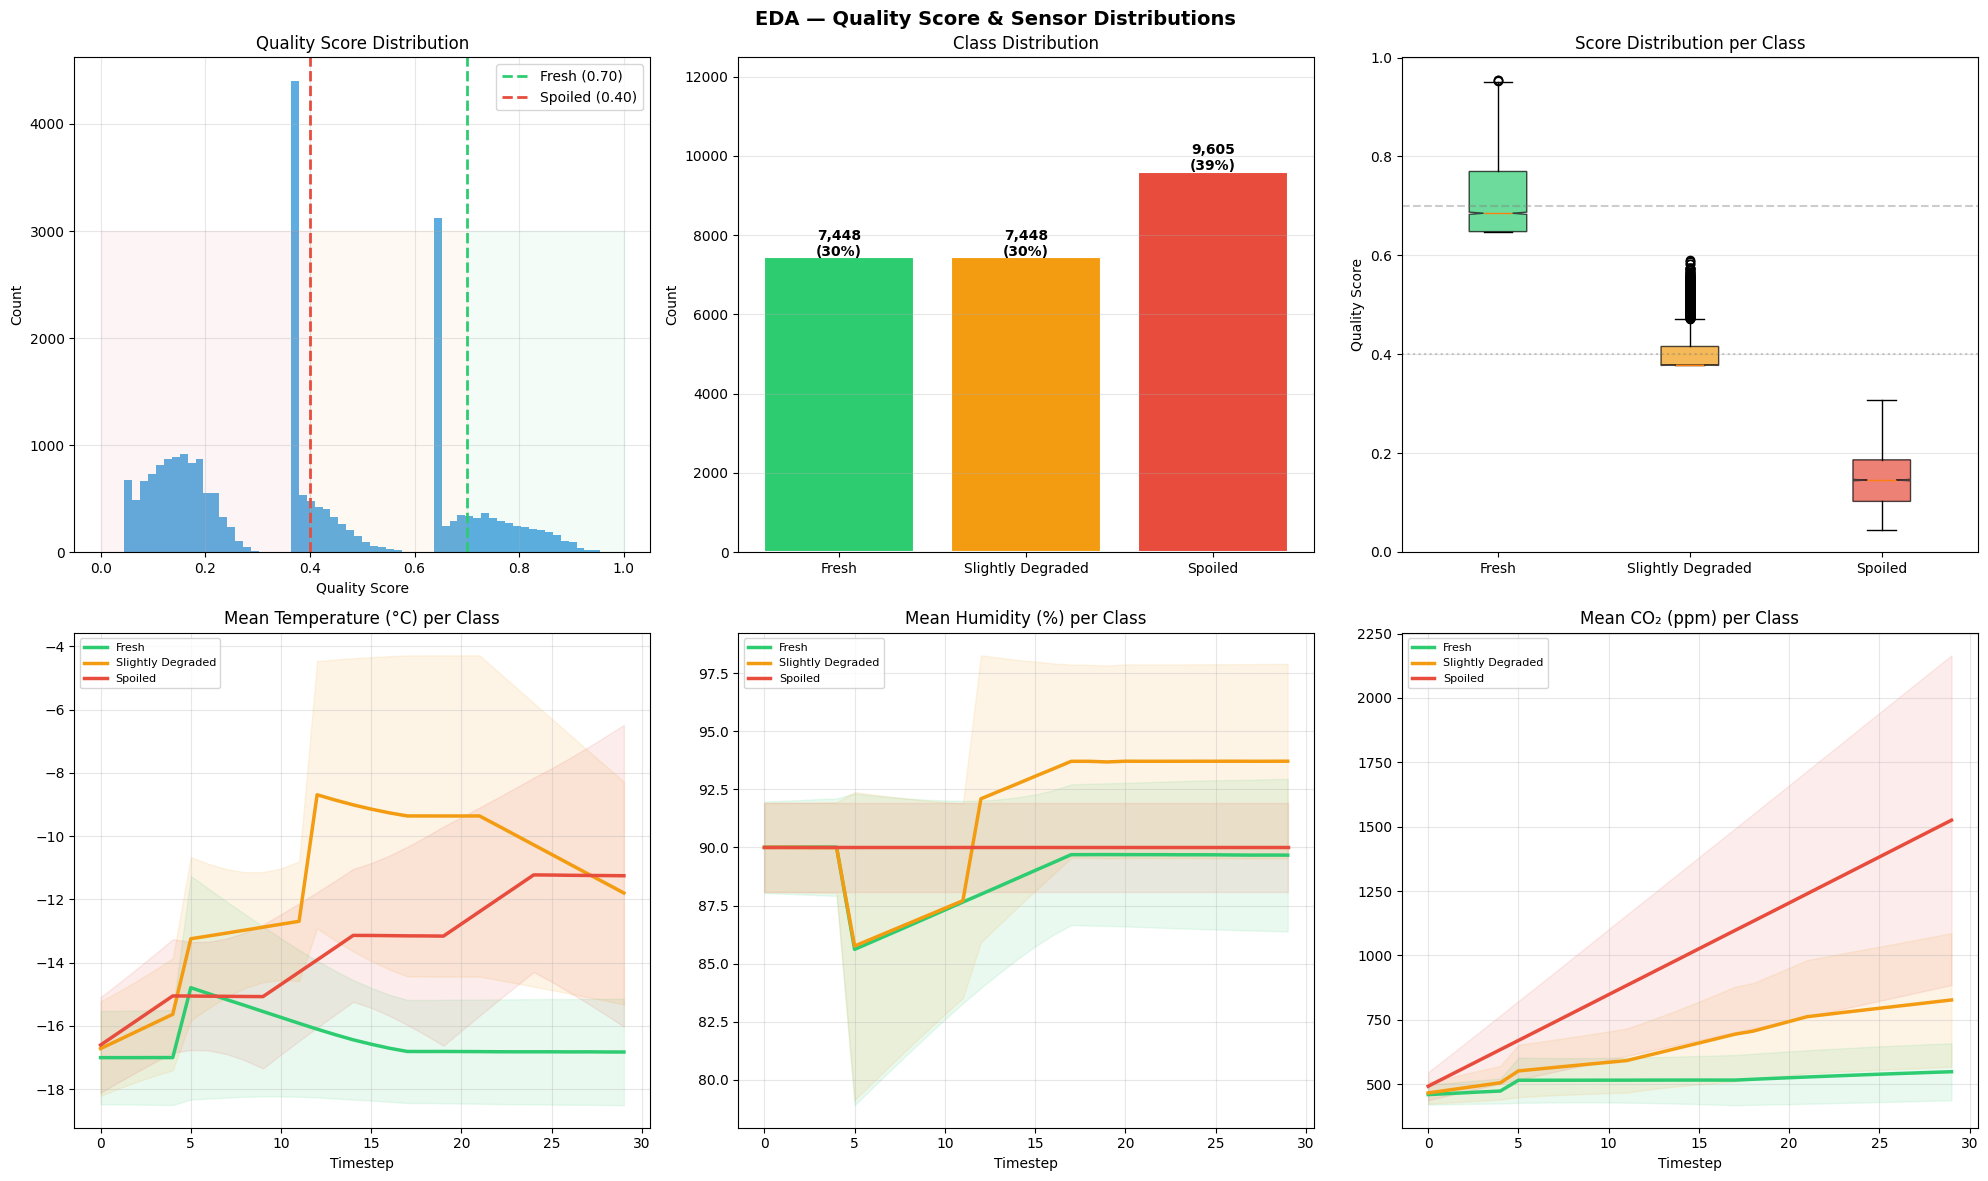

Saved: eda_01_overview.png


In [ ]:
# ================================================================
# CELL 7: EDA — Quality Distribution + Sensor Profiles
# ================================================================

all_scores  = np.concatenate([train_scores[:N_TRAIN], val_scores, test_scores])
all_classes = np.concatenate([TRAIN_LABELS, VAL_LABELS, TEST_LABELS])
all_seqs    = np.vstack([train_seqs[:N_TRAIN], val_seqs, test_seqs])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EDA — Quality Score & Sensor Distributions',
             fontsize=14, fontweight='bold')

# Quality score histogram
ax = axes[0][0]
ax.hist(all_scores, bins=60, color='#3498db', alpha=0.8, edgecolor='none')
ax.axvline(0.70, color='#2ecc71', ls='--', lw=2, label='Fresh (0.70)')
ax.axvline(0.40, color='#e74c3c', ls='--', lw=2, label='Spoiled (0.40)')
ax.fill_betweenx([0, 3000], 0.70, 1.00, alpha=0.05, color='#2ecc71')
ax.fill_betweenx([0, 3000], 0.40, 0.70, alpha=0.05, color='#f39c12')
ax.fill_betweenx([0, 3000], 0.00, 0.40, alpha=0.05, color='#e74c3c')
ax.set_xlabel('Quality Score'); ax.set_ylabel('Count')
ax.set_title('Quality Score Distribution')
ax.legend(); ax.grid(alpha=0.3)

# Class bar chart
ax = axes[0][1]
counts = [(all_classes == i).sum() for i in range(3)]
bars   = ax.bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='white', lw=1.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{cnt:,}\n({cnt/len(all_classes)*100:.0f}%)',
            ha='center', fontweight='bold', fontsize=10)
ax.set_title('Class Distribution')
ax.set_ylabel('Count'); ax.set_ylim(0, max(counts)*1.3)
ax.grid(axis='y', alpha=0.3)

# Score by class boxplot
ax = axes[0][2]
data = [all_scores[all_classes == i] for i in range(3)]
bp   = ax.boxplot(data, patch_artist=True, labels=CLASS_NAMES, notch=True)
for patch, col in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.axhline(0.70, color='gray', ls='--', alpha=0.4)
ax.axhline(0.40, color='gray', ls=':',  alpha=0.4)
ax.set_ylabel('Quality Score')
ax.set_title('Score Distribution per Class')
ax.grid(axis='y', alpha=0.3)

# Mean sensor profiles per class (Temp, Humid, CO2)
feat_names  = ['Temperature (°C)', 'Humidity (%)', 'CO₂ (ppm)']
feat_colors = ['#e74c3c', '#3498db', '#8e44ad']
t = np.arange(TIMESTEPS)
for fi, (fname, fcol) in enumerate(zip(feat_names, feat_colors)):
    ax = axes[1][fi]
    for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        mask = all_classes == ci
        mean = all_seqs[mask, :, fi].mean(axis=0)
        std  = all_seqs[mask, :, fi].std(axis=0)
        ax.plot(t, mean, color=ccol, lw=2.5, label=cname)
        ax.fill_between(t, mean-std, mean+std, alpha=0.1, color=ccol)
    ax.set_title(f'Mean {fname} per Class')
    ax.set_xlabel('Timestep'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda_01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_01_overview.png')

---
## CELL 8 — EDA: Arrhenius Curves + Correlation + 3D

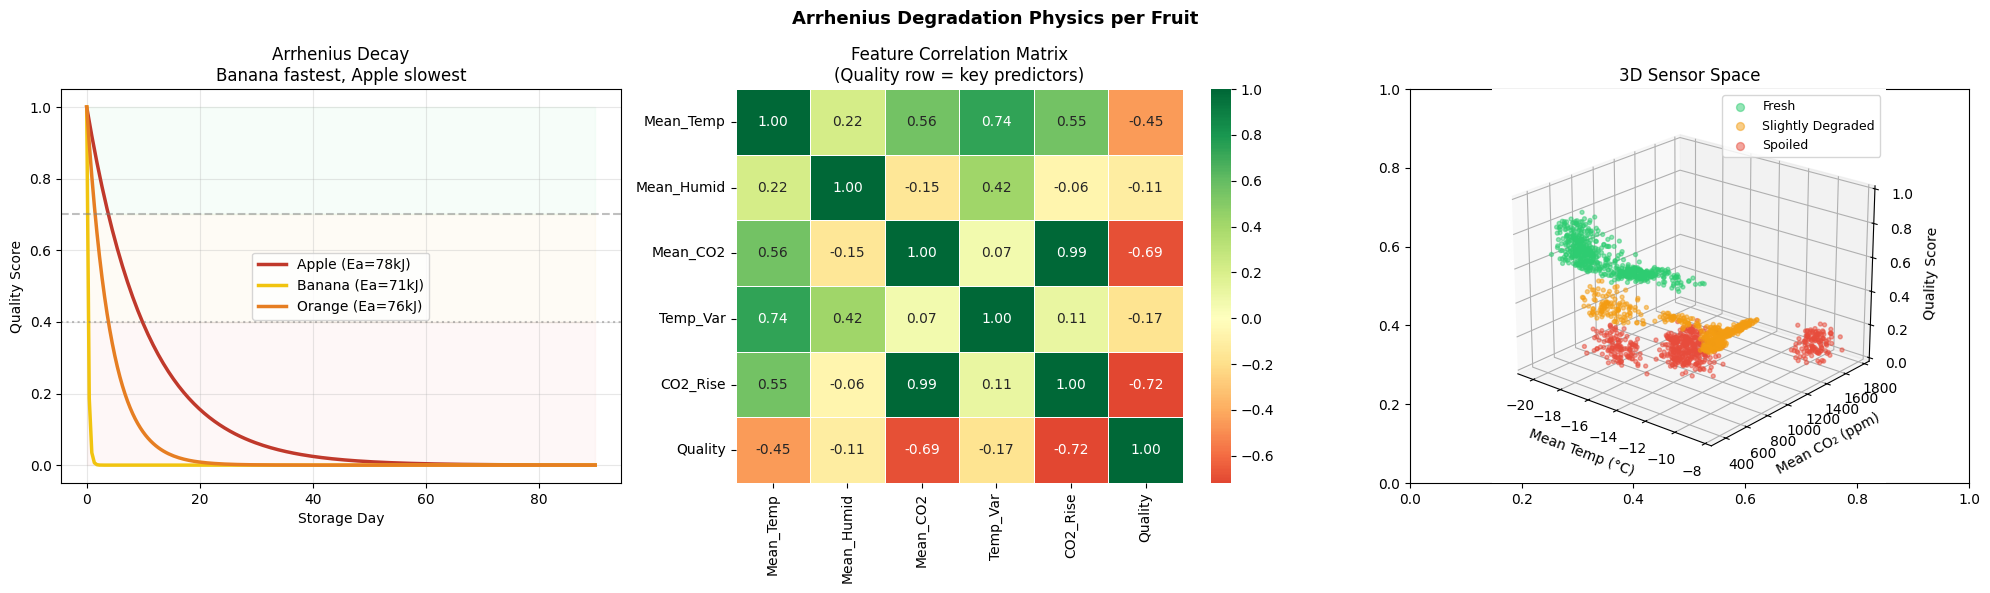

Saved: eda_02_physics.png


In [ ]:
# ================================================================
# CELL 8: EDA — Arrhenius Physics + Correlations + 3D Space
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Arrhenius Degradation Physics per Fruit',
             fontsize=13, fontweight='bold')

# Decay curves
days = np.linspace(0, 90, 200)
for fruit, fcol in zip(FRUIT_LIST, FRUIT_COLORS):
    p  = FRUIT_PARAMS[fruit]
    k  = 1e10 * math.exp(-p['Ea'] / (R_GAS * (p['base_temp'] + 273.15)))
    qs = [math.exp(-k * d * 86400) for d in days]
    axes[0].plot(days, qs, color=fcol, lw=2.5,
                 label=f"{fruit.capitalize()} (Ea={p['Ea']//1000}kJ)")
axes[0].axhline(0.70, color='gray', ls='--', alpha=0.5)
axes[0].axhline(0.40, color='gray', ls=':',  alpha=0.5)
axes[0].fill_between(days, 0.70, 1.0,  alpha=0.04, color='#2ecc71')
axes[0].fill_between(days, 0.40, 0.70, alpha=0.04, color='#f39c12')
axes[0].fill_between(days, 0.0,  0.40, alpha=0.04, color='#e74c3c')
axes[0].set_xlabel('Storage Day'); axes[0].set_ylabel('Quality Score')
axes[0].set_title('Arrhenius Decay\nBanana fastest, Apple slowest')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Correlation heatmap
df_eda = pd.DataFrame({
    'Mean_Temp':  all_seqs[:,:,0].mean(axis=1),
    'Mean_Humid': all_seqs[:,:,1].mean(axis=1),
    'Mean_CO2':   all_seqs[:,:,2].mean(axis=1),
    'Temp_Var':   all_seqs[:,:,0].var(axis=1),
    'CO2_Rise':   all_seqs[:,:,2][:,-1] - all_seqs[:,:,2][:,0],
    'Quality':    all_scores,
})
corr = df_eda.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, center=0)
axes[1].set_title('Feature Correlation Matrix\n'
                  '(Quality row = key predictors)')

# 3D sensor space
ax = fig.add_subplot(1, 3, 3, projection='3d')
for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = all_classes == ci
    idx  = np.where(mask)[0][:600]
    ax.scatter(df_eda.loc[idx,'Mean_Temp'],
               df_eda.loc[idx,'Mean_CO2'],
               df_eda.loc[idx,'Quality'],
               c=ccol, s=8, alpha=0.5, label=cname)
ax.set_xlabel('Mean Temp (°C)')
ax.set_ylabel('Mean CO₂ (ppm)')
ax.set_zlabel('Quality Score')
ax.set_title('3D Sensor Space')
ax.legend(fontsize=9, markerscale=2)
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda_02_physics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_02_physics.png')

---
## CELL 9 — Scale Features + Prepare Training Data

In [ ]:
# ================================================================
# CELL 9: Scale + Prepare
# Splits already done — just scale and convert labels
# ================================================================

# Fit scaler on first N_TRAIN synthetic rows only (no leakage)
scaler = MinMaxScaler()
scaler.fit(train_seqs[:N_TRAIN].reshape(-1, N_FEATURES))

def scale(seqs):
    n = seqs.shape[0]
    return scaler.transform(
        seqs.reshape(-1, N_FEATURES)
    ).reshape(n, TIMESTEPS, N_FEATURES).astype(np.float32)

X_train = scale(train_seqs)   # may include Mendeley rows
X_val   = scale(val_seqs)
X_test  = scale(test_seqs)

y_sc_train = train_scores.astype(np.float32)
y_sc_val   = val_scores.astype(np.float32)
y_sc_test  = test_scores.astype(np.float32)

y_cl_train = to_categorical(TRAIN_LABELS_FULL, 3)
y_cl_val   = to_categorical(VAL_LABELS,        3)
y_cl_test  = to_categorical(TEST_LABELS,       3)

cw_arr  = compute_class_weight('balanced',
                               classes=np.arange(3),
                               y=TRAIN_LABELS_FULL)
CLS_WTS = dict(enumerate(cw_arr))

print('Data preparation complete:')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}    ← exactly {N_VAL} (M1 val count)')
print(f'  X_test  : {X_test.shape}   ← exactly {N_TEST} (M1 test count)')
print(f'  Class weights: {CLS_WTS}')

Data preparation complete:
  X_train : (15373, 30, 4)
  X_val   : (5632, 30, 4)    ← exactly 5632 (M1 val count)
  X_test  : (3862, 30, 4)   ← exactly 3862 (M1 test count)
  Class weights: {0: np.float64(1.1232646500073067), 1: np.float64(1.1232646500073067), 2: np.float64(0.8200245372592948)}


---
## CELL 10 — Build BiLSTM + Attention Model

In [ ]:
# ================================================================
# CELL 10 (FIXED): Build model — list outputs instead of dict
# ================================================================

class AttentionLayer(layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)

    def call(self, h):
        score   = self.V(tf.nn.tanh(self.W(h)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * h, axis=1)
        return context, tf.squeeze(weights, -1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.W.units})
        return cfg


inp = layers.Input(shape=(TIMESTEPS, N_FEATURES), name='sensor_input')

x = layers.Bidirectional(
    layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
    name='bilstm_1')(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

attn        = AttentionLayer(64, name='attention')
ctx, attn_w = attn(x)

x2 = layers.Bidirectional(
    layers.LSTM(64, return_sequences=False, dropout=0.1),
    name='bilstm_2')(x)
x2 = layers.BatchNormalization()(x2)

merged = layers.Concatenate(name='merge')([ctx, x2])
merged = layers.Dropout(0.3)(merged)

emb = layers.Dense(256, activation='relu', name='embedding')(merged)
emb = layers.BatchNormalization()(emb)
emb = layers.Dropout(0.2)(emb)

# Output 0: quality score
sc_out = layers.Dense(64, activation='relu')(emb)
sc_out = layers.Dense(1,  activation='sigmoid', name='quality_score')(sc_out)

# Output 1: quality class
cl_out = layers.Dense(64, activation='relu')(emb)
cl_out = layers.Dense(3,  activation='softmax', name='quality_class')(cl_out)

model = models.Model(inputs=inp, outputs=[sc_out, cl_out],
                     name='BiLSTM_FrozenFruit')

# Compile with LIST-based losses (not dict) — fixes TF 2.19 bug
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=['mse', 'categorical_crossentropy'],
    loss_weights=[1.0, 0.5],
    metrics=[['mae'], ['accuracy']]
)

model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "BiLSTM_FrozenFruit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 30, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 30, 256)   │    136,192 │ sensor_input[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ bilstm_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │    164,352 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, 256),     │     16,448 │ dropout_3[0][0]   │
│ (AttentionLayer)    │ (None, 30)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ bilstm_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 384)       │          0 │ attention[0][0],  │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 384)       │          0 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding (Dense)   │ (None, 256)       │     98,560 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ embedding[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     16,448 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     16,448 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_score       │ (None, 1)         │         65 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_class       │ (None, 3)         │        195 │ dense_7[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 451,268 (1.72 MB)

 Trainable params: 449,988 (1.72 MB)

 Non-trainable params: 1,280 (5.00 KB)


Total parameters: 451,268


In [ ]:
# DIAGNOSTIC — run this before Cell 11
print(f'X_train shape      : {X_train.shape}')
print(f'y_sc_train shape   : {y_sc_train.shape}')
print(f'y_cl_train shape   : {y_cl_train.shape}')
print(f'y_sc_train sample  : {y_sc_train[:5]}')
print(f'y_cl_train sample  : {y_cl_train[:5]}')
print(f'Any NaN in X_train : {np.isnan(X_train).any()}')
print(f'Any NaN in scores  : {np.isnan(y_sc_train).any()}')

X_train shape      : (15373, 30, 4)
y_sc_train shape   : (15373,)
y_cl_train shape   : (15373, 3)
y_sc_train sample  : [0.74629015 0.648      0.7412442  0.7553054  0.648     ]
y_cl_train sample  : [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
Any NaN in X_train : False
Any NaN in scores  : False


---
## CELL 11 — Train

In [ ]:
# ================================================================
# CELL 11 (FIXED): Train — list outputs, no class/sample weight
# ================================================================

BATCH  = 128
EPOCHS = 30

cbs = [
    callbacks.EarlyStopping(
        monitor='val_quality_score_mae',
        mode='min',
        patience=10,
        restore_best_weights=True,
        verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.4,
        patience=5,
        min_lr=1e-7,
        verbose=1),
    callbacks.ModelCheckpoint(
        '/content/best_bilstm.keras',
        monitor='val_quality_score_mae',
        mode='min',
        save_best_only=True,
        verbose=1)
]

print(f'Training on   {len(X_train):,} sequences...')
print(f'Validating on {len(X_val):,} sequences...')
print(f'Batch={BATCH} | Max epochs={EPOCHS}\n')

# Pass outputs as LIST not dict
history = model.fit(
    X_train,
    [y_sc_train, y_cl_train],          # ← list, not dict
    validation_data=(
        X_val,
        [y_sc_val, y_cl_val]           # ← list, not dict
    ),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs
)

model.load_weights('/content/best_bilstm.keras')

# History keys use index-based names when compiled with lists
# Check what keys are available
print('\nAvailable history keys:')
print(list(history.history.keys()))

# Find MAE and accuracy keys dynamically
mae_key = [k for k in history.history if 'mae' in k and 'val' in k][0]
acc_key = [k for k in history.history if 'acc' in k and 'val' in k][0]

best_mae = min(history.history[mae_key])
best_acc = max(history.history[acc_key])
print(f'\nBest val MAE      : {best_mae:.4f}  '
      f'{"PASS" if best_mae < 0.15 else "NEEDS MORE TRAINING"}')
print(f'Best val Accuracy : {best_acc:.4f}  ({best_acc*100:.1f}%)  '
      f'{"PASS" if best_acc > 0.80 else "NEEDS MORE TRAINING"}')

Training on   15,373 sequences...
Validating on 5,632 sequences...
Batch=128 | Max epochs=30

Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 0.1745 - quality_class_accuracy: 0.8594 - quality_class_loss: 0.3003 - quality_score_loss: 0.0244 - quality_score_mae: 0.1164
Epoch 1: val_quality_score_mae improved from None to 0.15789, saving model to /content/best_bilstm.keras

Epoch 1: finished saving model to /content/best_bilstm.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 72s 594ms/step - loss: 0.1617 - quality_class_accuracy: 0.8669 - quality_class_loss: 0.2793 - quality_score_loss: 0.0219 - quality_score_mae: 0.1099 - val_loss: 0.7166 - val_quality_class_accuracy: 0.4334 - val_quality_class_loss: 1.3673 - val_quality_score_loss: 0.0330 - val_quality_score_mae: 0.1579 - learning_rate: 0.0010
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - loss: 0.1503 - quality_class_accuracy: 0.8747 - quality_class_loss: 0.2606 - quality_score_loss: 0.0200 - quality_score_mae: 0.1035
Epoch 2

---
## CELL 12 — Training Curves + Full Evaluation

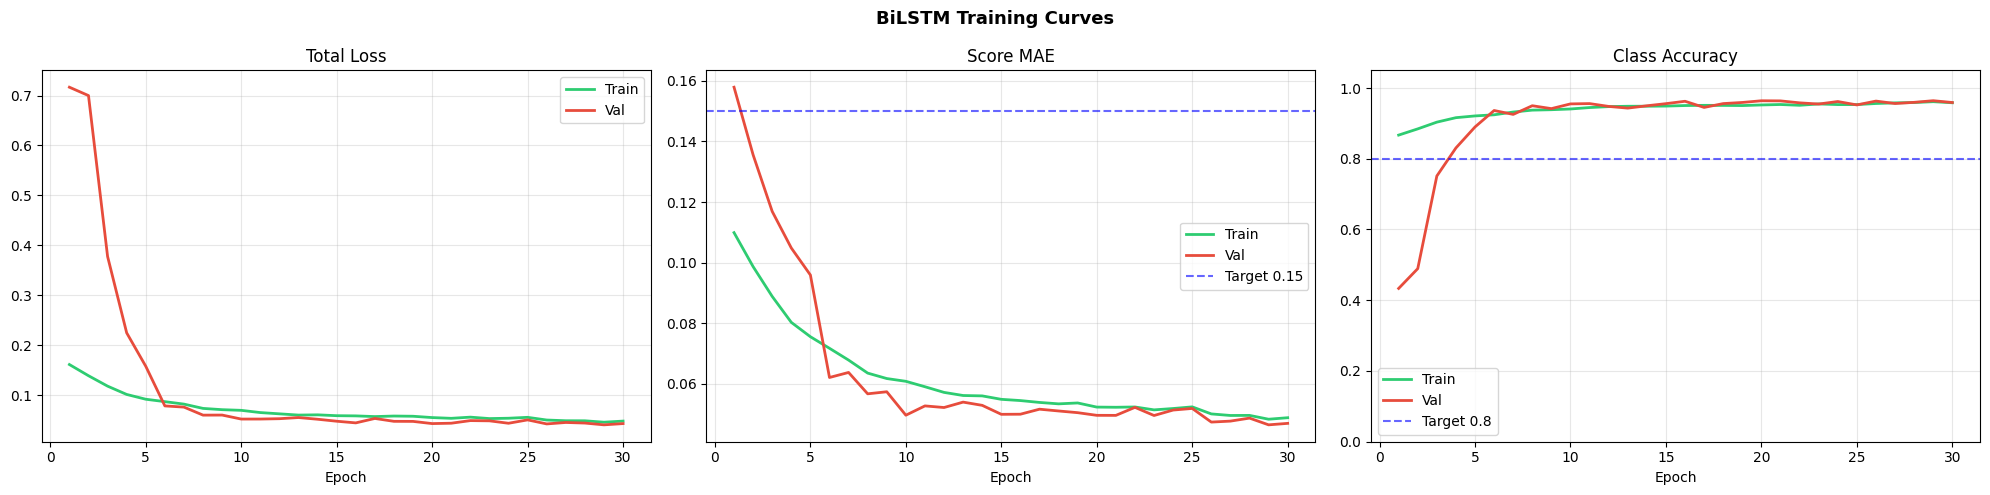

Evaluating on test set...

TEST SET RESULTS
RMSE     : 0.0647  target <0.15  → PASS
MAE      : 0.0469
R²       : 0.9290
Accuracy : 0.9573 (95.7%)  → PASS

                   precision    recall  f1-score   support

            Fresh       0.90      0.96      0.93      1164
Slightly Degraded       0.96      0.89      0.93      1164
          Spoiled       1.00      1.00      1.00      1534

         accuracy                           0.96      3862
        macro avg       0.95      0.95      0.95      3862
     weighted avg       0.96      0.96      0.96      3862



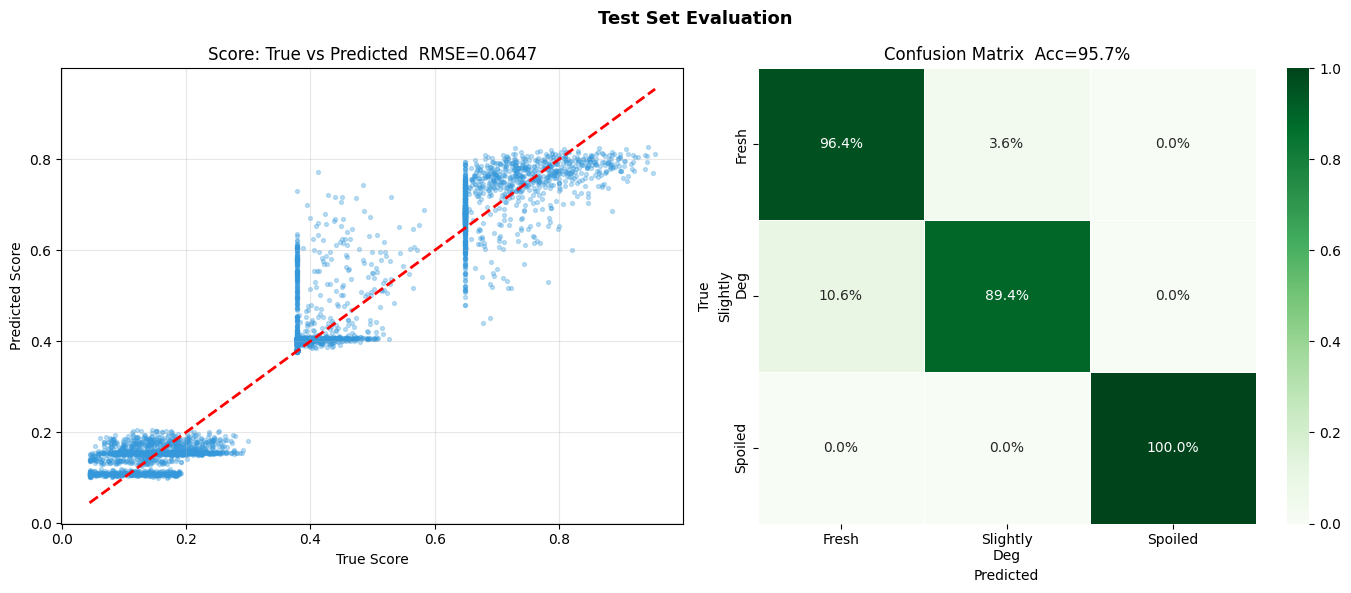

In [ ]:
# ================================================================
# CELL 12: Training Curves + Test Set Evaluation
# ================================================================

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('BiLSTM Training Curves', fontsize=13, fontweight='bold')
eps = range(1, len(history.history['loss'])+1)

for ax, key, title, target in [
    (axes[0], 'loss',                   'Total Loss',        None),
    (axes[1], 'quality_score_mae',      'Score MAE',         0.15),
    (axes[2], 'quality_class_accuracy', 'Class Accuracy',    0.80),
]:
    ax.plot(eps, history.history[key],           color='#2ecc71', lw=2, label='Train')
    ax.plot(eps, history.history[f'val_{key}'],  color='#e74c3c', lw=2, label='Val')
    if target:
        ax.axhline(target, color='blue', ls='--', alpha=0.6,
                   label=f'Target {target}')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
    if 'accuracy' in key: ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUT_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test evaluation
print('Evaluating on test set...')
pred_sc, pred_prob = model.predict(X_test, verbose=0)
pred_sc  = pred_sc.flatten()
pred_cls = np.argmax(pred_prob, axis=1)
true_cls = np.argmax(y_cl_test, axis=1)

rmse = np.sqrt(mean_squared_error(y_sc_test, pred_sc))
mae  = mean_absolute_error(y_sc_test, pred_sc)
r2   = r2_score(y_sc_test, pred_sc)
acc  = (pred_cls == true_cls).mean()

print('\n' + '='*50)
print('TEST SET RESULTS')
print('='*50)
print(f'RMSE     : {rmse:.4f}  target <0.15  → {"PASS" if rmse<0.15 else "FAIL"}')
print(f'MAE      : {mae:.4f}')
print(f'R²       : {r2:.4f}')
print(f'Accuracy : {acc:.4f} ({acc*100:.1f}%)  → {"PASS" if acc>0.80 else "FAIL"}')
print()
print(classification_report(true_cls, pred_cls, target_names=CLASS_NAMES))

# Confusion matrix + scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Test Set Evaluation', fontsize=13, fontweight='bold')

axes[0].scatter(y_sc_test, pred_sc, alpha=0.3, s=8, c='#3498db')
mn, mx = y_sc_test.min(), y_sc_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=2)
axes[0].set_xlabel('True Score'); axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Score: True vs Predicted  RMSE={rmse:.4f}')
axes[0].grid(alpha=0.3)

cm   = confusion_matrix(true_cls, pred_cls)
cm_n = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Greens', ax=axes[1],
            xticklabels=['Fresh','Slightly\nDeg','Spoiled'],
            yticklabels=['Fresh','Slightly\nDeg','Spoiled'],
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix  Acc={acc:.1%}')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(OUT_DIR/'evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 13 — Attention Visualization

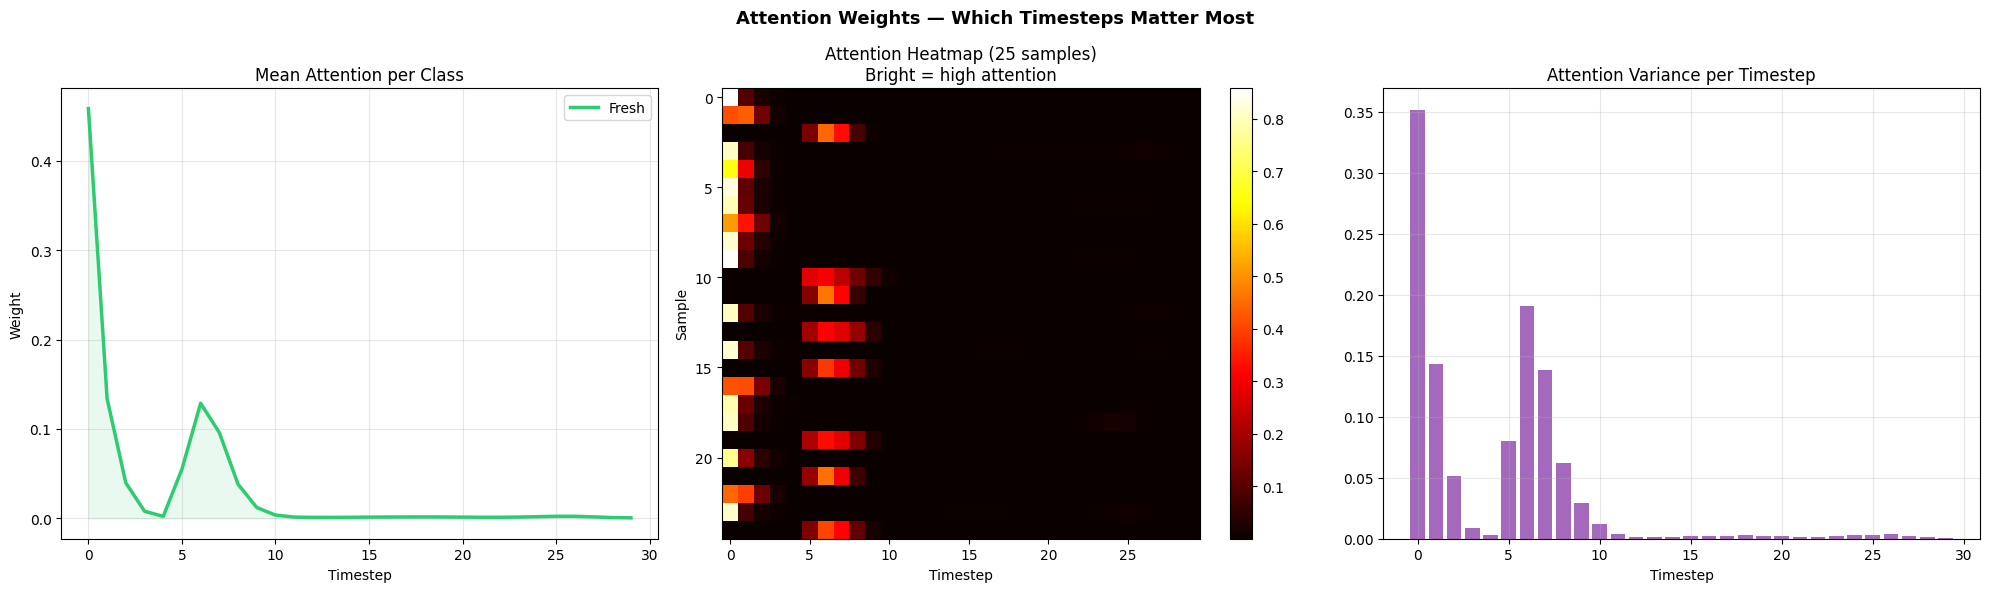

Saved: attention.png


In [ ]:
# ================================================================
# CELL 13: Attention Visualization
# Shows which timesteps the model focuses on per class
# ================================================================

attn_extractor = tf.keras.Model(
    inputs  = model.input,
    outputs = model.get_layer('attention').output
)
ctx_out, attn_weights = attn_extractor.predict(X_test[:300], verbose=0)
tc = true_cls[:300]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Attention Weights — Which Timesteps Matter Most',
             fontsize=13, fontweight='bold')

# Mean attention per class
ax = axes[0]
for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = tc == ci
    if mask.sum() > 0:
        m = attn_weights[mask].mean(axis=0)
        ax.plot(m, color=ccol, lw=2.5, label=cname)
        ax.fill_between(range(TIMESTEPS), m, alpha=0.1, color=ccol)
ax.set_title('Mean Attention per Class')
ax.set_xlabel('Timestep'); ax.set_ylabel('Weight')
ax.legend(); ax.grid(alpha=0.3)

# Heatmap
im = axes[1].imshow(attn_weights[:25], aspect='auto',
                     cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Attention Heatmap (25 samples)\nBright = high attention')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Sample')

# Variance
axes[2].bar(range(TIMESTEPS), attn_weights.std(axis=0),
            color='#8e44ad', alpha=0.8)
axes[2].set_title('Attention Variance per Timestep')
axes[2].set_xlabel('Timestep'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention.png')

---
## CELL 14 — 90-Day Quality Forecast

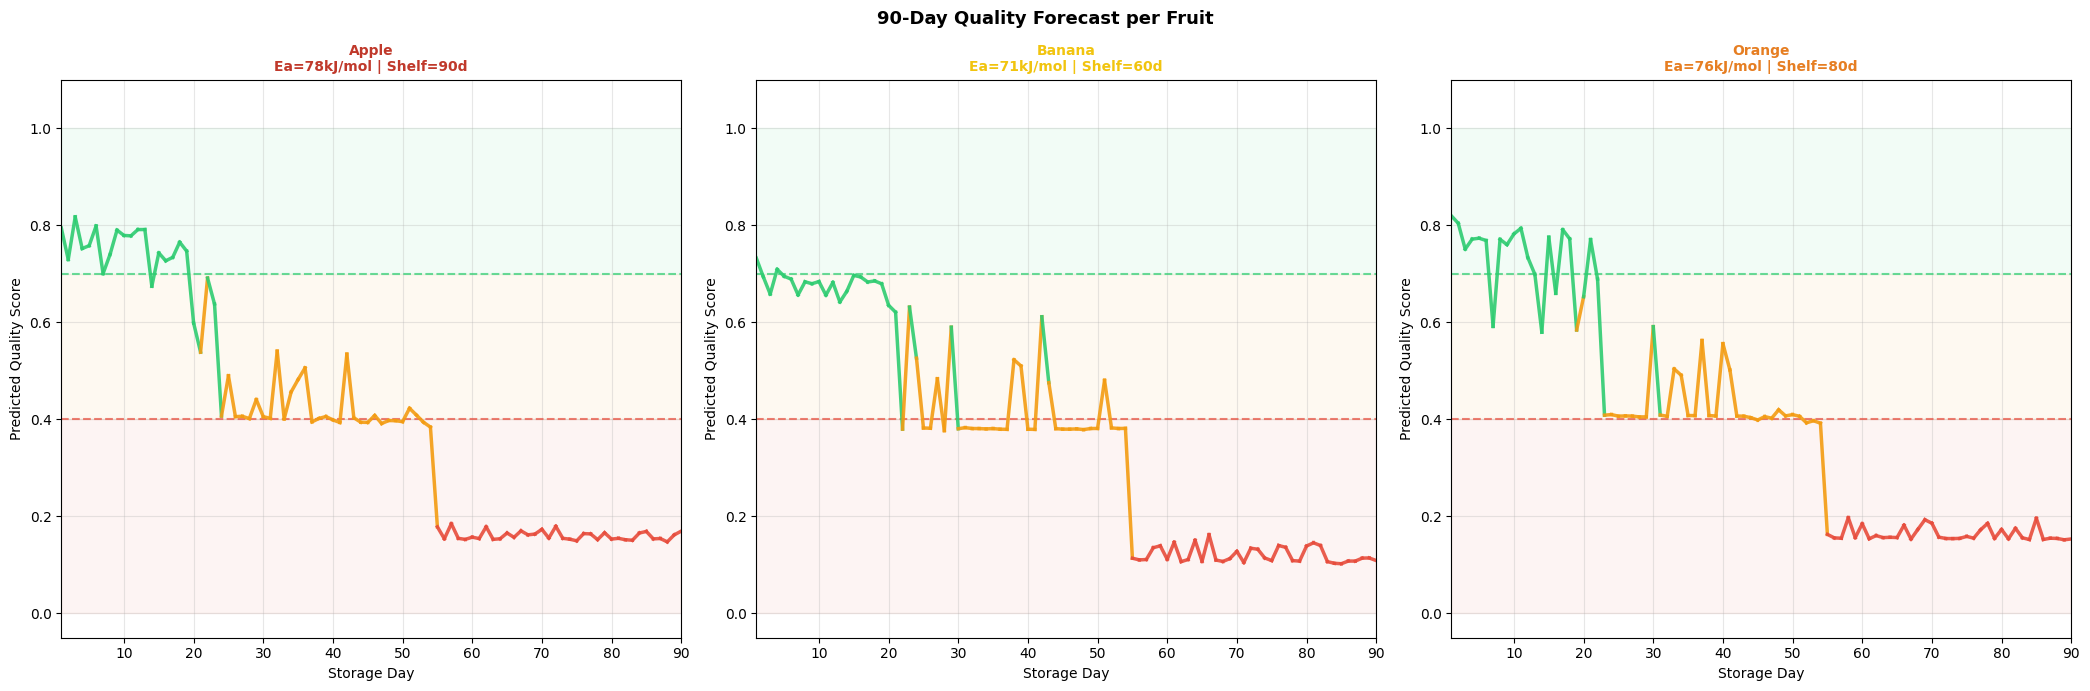

In [ ]:
# ================================================================
# CELL 14: 90-Day Forecast per Fruit
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('90-Day Quality Forecast per Fruit',
             fontsize=13, fontweight='bold')

for fi, (fruit, fcol) in enumerate(zip(FRUIT_LIST, FRUIT_COLORS)):
    ax   = axes[fi]
    days = np.arange(1, 91)

    day_seqs = []
    for d in days:
        cls = 0 if d < 22 else (1 if d < 55 else 2)
        sc  = random.choice(CLASS_CONDITIONS[cls]['scenarios'])
        day_seqs.append(make_sequence(fruit, sc, int(d)))

    day_arr    = np.array(day_seqs, dtype=np.float32)
    day_scaled = scaler.transform(
        day_arr.reshape(-1, N_FEATURES)
    ).reshape(90, TIMESTEPS, N_FEATURES).astype(np.float32)

    pred_s, pred_c = model.predict(day_scaled, verbose=0)
    pred_s = pred_s.flatten()
    pred_c = np.argmax(pred_c, axis=1)

    ax.fill_between(days, 0.70, 1.0,  alpha=0.06, color='#2ecc71')
    ax.fill_between(days, 0.40, 0.70, alpha=0.06, color='#f39c12')
    ax.fill_between(days, 0.00, 0.40, alpha=0.06, color='#e74c3c')
    ax.axhline(0.70, color='#2ecc71', ls='--', lw=1.5, alpha=0.7)
    ax.axhline(0.40, color='#e74c3c', ls='--', lw=1.5, alpha=0.7)

    for i in range(len(days)-1):
        ax.plot(days[i:i+2], pred_s[i:i+2],
                color=CLASS_COLORS[pred_c[i]], lw=2.5, alpha=0.9)

    p = FRUIT_PARAMS[fruit]
    ax.set_title(f'{fruit.capitalize()}\n'
                 f'Ea={p["Ea"]//1000}kJ/mol | '
                 f'Shelf={p["shelf_days"]}d',
                 fontsize=10, fontweight='bold', color=fcol)
    ax.set_xlabel('Storage Day')
    ax.set_ylabel('Predicted Quality Score')
    ax.set_xlim(1, 90); ax.set_ylim(-0.05, 1.1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'forecast_90day.png', dpi=150, bbox_inches='tight')
plt.show()


---
## CELL 15 — Extract & Save 256-dim Embeddings for Module 3

Embedding output shape: (None, 256)

Extracting embeddings...
  Train embeddings : (15007, 256)  ← matches M1 train (15007)
  Val   embeddings : (5632, 256)    ← matches M1 val   (5632)
  Test  embeddings : (3862, 256)   ← matches M1 test  (3862)

All embeddings saved!
Running t-SNE...


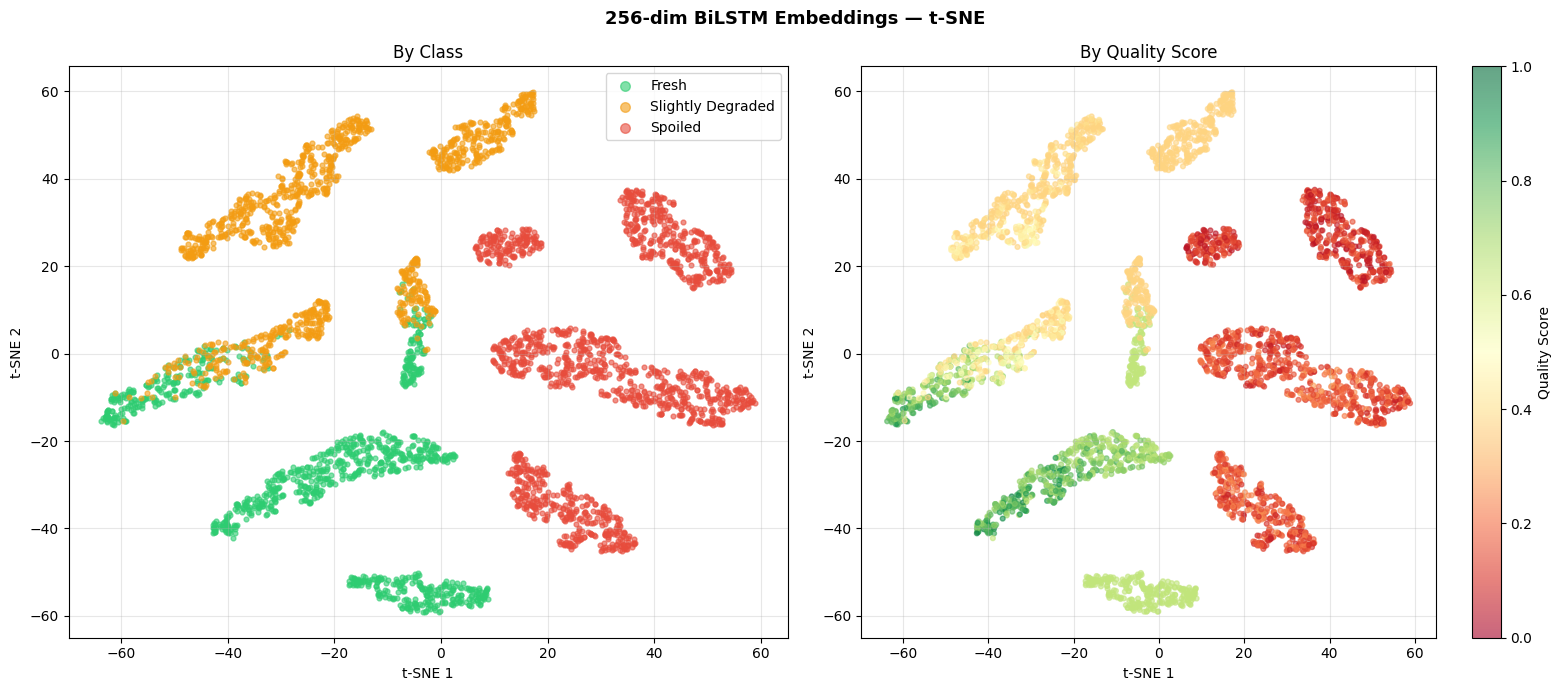


WHAT MODULE 3 WILL DO WITH THESE
  M1 CNN embeddings  : (N, 1280)  visual features
  M2 BiLSTM embeddings: (N,  256)  temporal features
  Concatenated        : (N, 1536)  Digital Twin state
  Row i = same image = same class in both


In [ ]:
# ================================================================
# CELL 15: Extract 256-dim Embeddings
# These are index-aligned with Module 1 images
# Module 3 loads both and concatenates row by row
# ================================================================

emb_model = tf.keras.Model(
    inputs  = model.input,
    outputs = model.get_layer('embedding').output,
    name    = 'bilstm_embedding_extractor'
)
print(f'Embedding output shape: {emb_model.output_shape}')

# Extract from the first N_TRAIN/N_VAL/N_TEST rows
# (strips Mendeley augmentation rows from train embeddings)
print('\nExtracting embeddings...')
train_emb = emb_model.predict(X_train[:N_TRAIN], verbose=0, batch_size=128)
val_emb   = emb_model.predict(X_val,             verbose=0, batch_size=128)
test_emb  = emb_model.predict(X_test,            verbose=0, batch_size=128)

print(f'  Train embeddings : {train_emb.shape}  ← matches M1 train ({N_TRAIN})')
print(f'  Val   embeddings : {val_emb.shape}    ← matches M1 val   ({N_VAL})')
print(f'  Test  embeddings : {test_emb.shape}   ← matches M1 test  ({N_TEST})')

# Save
EMB_DIR = Path('/content/embeddings_module2')
EMB_DIR.mkdir(exist_ok=True)

np.save(EMB_DIR/'train_bilstm_embeddings.npy', train_emb)
np.save(EMB_DIR/'val_bilstm_embeddings.npy',   val_emb)
np.save(EMB_DIR/'test_bilstm_embeddings.npy',  test_emb)
np.save(EMB_DIR/'train_quality_scores.npy',    y_sc_train[:N_TRAIN])
np.save(EMB_DIR/'val_quality_scores.npy',      y_sc_val)
np.save(EMB_DIR/'test_quality_scores.npy',     y_sc_test)
np.save(EMB_DIR/'train_classes.npy',           TRAIN_LABELS)
np.save(EMB_DIR/'val_classes.npy',             VAL_LABELS)
np.save(EMB_DIR/'test_classes.npy',            TEST_LABELS)
np.save(EMB_DIR/'test_pred_scores.npy',        pred_sc)
np.save(EMB_DIR/'test_pred_classes.npy',       pred_cls)

with open(EMB_DIR/'sensor_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('\nAll embeddings saved!')

# t-SNE visualization
print('Running t-SNE...')
pca  = PCA(n_components=30, random_state=42)
t_p  = pca.fit_transform(test_emb)
tsne = TSNE(n_components=2, perplexity=30, n_iter=800, random_state=42)
t_2d = tsne.fit_transform(t_p)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('256-dim BiLSTM Embeddings — t-SNE',
             fontsize=13, fontweight='bold')
for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = TEST_LABELS == ci
    axes[0].scatter(t_2d[mask,0], t_2d[mask,1],
                    c=ccol, s=12, alpha=0.6, label=cname)
axes[0].set_title('By Class'); axes[0].legend(fontsize=10, markerscale=2)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].grid(alpha=0.3)

sc_plot = axes[1].scatter(t_2d[:,0], t_2d[:,1],
                           c=y_sc_test, cmap='RdYlGn',
                           s=12, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc_plot, ax=axes[1], label='Quality Score')
axes[1].set_title('By Quality Score')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('WHAT MODULE 3 WILL DO WITH THESE')
print('='*55)
print(f'  M1 CNN embeddings  : (N, 1280)  visual features')
print(f'  M2 BiLSTM embeddings: (N,  256)  temporal features')
print(f'  Concatenated        : (N, 1536)  Digital Twin state')
print(f'  Row i = same image = same class in both')